# Time Series Foundation Models for Financial Forecasting

**Docker image**: `ml4t-gpu`

This notebook evaluates Time Series Foundation Models (TSFMs) on ETF return
prediction, testing the key question from recent literature:

**Do pre-trained TSFMs transfer to finance zero-shot?**

**Models Evaluated**:
- **Chronos** (Amazon): T5-based tokenization, probabilistic forecasting
- **TTM** (IBM Granite): TinyTimeMixer, efficient MLP-based architecture
- **LSTM Baseline**: Task-specific training on domain data
- **Ridge Baseline**: Linear regression on flattened context windows

**Key References**:
- Rahimikia et al. (2025) survey: Zero-shot TSFMs fail on finance
- DELPHYNE (Ding et al., 2025): Negative transfer in finance
- Rasul et al. (2024) Lag-Llama: Probabilistic forecasting

**Learning Objectives**:
- Run zero-shot inference with Chronos and TinyTimeMixer
- Compare pre-trained foundation models against task-specific baselines
- Understand why the transfer gap exists for financial time series
- Use sktime's ChronosForecaster wrapper for univariate forecasting

**Book Reference**: Chapter 13, Section 13.6 (Foundation Models)

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""Time Series Foundation Models — evaluate zero-shot Chronos and TTM against task-specific baselines."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from chronos import ChronosPipeline
from dl_sequences import load_dl_dataset, train_model
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:335: SyntaxWarning: 'return' in a 'finally' block
  return f
/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:337: SyntaxWarning: 'return' in a 'finally' block
  return self._get_more_data(ov, maxsize)


In [2]:
SEED = 42
CONTEXT_LENGTH = 60
# PREDICTION_LENGTH = 10 is held fixed across all zero-shot evaluations as a
# directional-signal probe — see the design note below for why it does not
# need to match the label horizon for this comparison.
PREDICTION_LENGTH = 10
EPOCHS = 30
BATCH_SIZE = 64
LR = 0.001
INFER_BATCH_SIZE = 1_024
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None
CHRONOS_NUM_SAMPLES = 10
# When True, a Chronos or TTM *runtime* (load/inference) failure raises rather
# than producing a missing row in the results table. The chronos and
# tsfm_public libraries are imported at module load, so they must be installed
# regardless of this flag — it governs runtime failures, not missing installs.
REQUIRE_FOUNDATION_MODELS = True

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)

print(f"Context length: {CONTEXT_LENGTH}")
print(f"Prediction length: {PREDICTION_LENGTH}")
print(f"Epochs: {EPOCHS}")

Using device: cuda
Context length: 60
Prediction length: 10
Epochs: 30


## Data Loading

We load ETF features and labels from the case study pipeline. For foundation
model evaluation we use univariate price-derived contexts (close returns)
alongside the multivariate feature set for the LSTM and Ridge baselines.

In [4]:
mds = load_dl_dataset("etfs")

FEATURE_COLS = mds.feature_names[:8]
TARGET_COL = mds.label_col

df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")
print(f"Rows after dropna: {len(df):,}")

Loaded etfs: 394,233 rows, 71 features, 99 entities, label=fwd_ret_21d
Features (8): ['ret_5d', 'ret_10d', 'ret_21d', 'ret_42d', 'ret_63d', 'ret_126d', 'ret_189d', 'ret_252d']
Target: fwd_ret_21d
Rows after dropna: 394,157


## Prepare Univariate Contexts

Foundation models expect univariate time series contexts. We extract
the first feature column (typically close returns) per symbol and build
sliding windows of length `CONTEXT_LENGTH`. Each window is paired with
the forward return label at the next timestep.

**Design note on horizon and target alignment.** The zero-shot baseline
below forecasts the *first feature column* for `PREDICTION_LENGTH` steps
and uses the mean of that forecast path as a directional score, which is
then compared cross-sectionally to the label `TARGET_COL`. The forecast
horizon (`PREDICTION_LENGTH = 10`) is held fixed across models and does
not necessarily match the label horizon — for the ETF case study used
here, the label is a multi-day forward return. The experiment is therefore
a *directional-signal probe*, not a calibrated forecast of the label
itself: it tests whether a zero-shot foundation model's mean forecast on
raw historical values produces a useful ranking of assets at the next
rebalance, against the same ranking from a task-specific baseline. Tying
`PREDICTION_LENGTH` to the label horizon and explicitly aggregating the
forecasted path into the same target definition would let foundation
models be evaluated on the label directly; that variation is left as an
exercise and would change the numerical comparisons that follow.

In [5]:
def prepare_univariate_contexts(
    df: pl.DataFrame,
    feature_col: str,
    target_col: str,
    context_length: int,
    date_col: str = "timestamp",
    symbol_col: str = "symbol",
) -> tuple[list[np.ndarray], np.ndarray, np.ndarray, np.ndarray]:
    """Sliding-window contexts of `feature_col` paired with `target_col` per symbol."""
    contexts, targets_list, dates_list, symbols_list = [], [], [], []
    for symbol in df.select(symbol_col).unique().to_series().to_list():
        sym_df = df.filter(pl.col(symbol_col) == symbol).sort(date_col)
        if len(sym_df) < context_length + 1:
            continue
        values = sym_df[feature_col].to_numpy().astype(np.float32)
        target_values = sym_df[target_col].to_numpy().astype(np.float32)
        dates = sym_df[date_col].to_numpy()
        for i in range(context_length, len(values)):
            ctx = values[i - context_length : i]
            if not np.isfinite(ctx).all():
                continue
            contexts.append(ctx)
            targets_list.append(target_values[i])
            dates_list.append(dates[i])
            symbols_list.append(symbol)
    return (
        contexts,
        np.array(targets_list, dtype=np.float32),
        np.array(dates_list),
        np.array(symbols_list),
    )

In [6]:
# Use the first feature as the univariate context series
CONTEXT_FEATURE = FEATURE_COLS[0]
print(f"Univariate context feature: {CONTEXT_FEATURE}")

contexts, targets, dates_arr, symbols_arr = prepare_univariate_contexts(
    df,
    CONTEXT_FEATURE,
    TARGET_COL,
    CONTEXT_LENGTH,
    date_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)
print(f"Total samples: {len(contexts):,}")

Univariate context feature: ret_5d


Total samples: 388,217


## Temporal Train/Test Split

We use a simple 60/20/20 temporal split (consistent with other Ch13 notebooks)
rather than walk-forward CV, since foundation model inference is expensive
and the pedagogical focus is on zero-shot vs trained comparison.

In [7]:
# Date-based 60/20/20 temporal split — sample-order indexing on asset-pooled
# sequences would split cross-asset, not temporally.
unique_dates = np.sort(np.unique(dates_arr))
train_end_date = unique_dates[int(len(unique_dates) * 0.6)]
val_end_date = unique_dates[int(len(unique_dates) * 0.8)]

train_idx = np.where(dates_arr < train_end_date)[0].tolist()
val_idx = np.where((dates_arr >= train_end_date) & (dates_arr < val_end_date))[0].tolist()
test_idx = np.where(dates_arr >= val_end_date)[0].tolist()

if MAX_TRAIN_SAMPLES and len(train_idx) > MAX_TRAIN_SAMPLES:
    train_idx = train_idx[-MAX_TRAIN_SAMPLES:]
if MAX_VAL_SAMPLES and len(val_idx) > MAX_VAL_SAMPLES:
    val_idx = val_idx[-MAX_VAL_SAMPLES:]
if MAX_TEST_SAMPLES and len(test_idx) > MAX_TEST_SAMPLES:
    test_idx = test_idx[-MAX_TEST_SAMPLES:]

test_dates = dates_arr[test_idx]
test_symbols = symbols_arr[test_idx]

print(f"Train: {len(train_idx):,}, Val: {len(val_idx):,}, Test: {len(test_idx):,}")

Train: 209,996, Val: 89,633, Test: 88,588


### Cross-sectional IC helper

Same per-date Spearman rank correlation used everywhere else in Chapter 13,
so the zero-shot foundation models are scored on the same yardstick as
the task-specific LSTM and Ridge baselines that follow.

In [8]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC across dates."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")

## Chronos Zero-Shot Forecasting

Chronos (Amazon) treats time series as discrete tokens via quantization,
using a T5-based encoder-decoder architecture pre-trained on diverse datasets.
We test whether these pre-trained representations transfer to ETF returns.

In [9]:
CHRONOS_SUCCESS = False
chronos_ic = 0.0

try:
    model_size = "small"
    print(f"Loading Chronos-{model_size}...")
    chronos = ChronosPipeline.from_pretrained(
        f"amazon/chronos-t5-{model_size}",
        device_map=str(DEVICE),
        torch_dtype=torch.float32,
    )
    contexts_test = [contexts[i] for i in test_idx]
    y_test_chronos = targets[test_idx]
    scores = []
    for i in range(0, len(contexts_test), BATCH_SIZE):
        batch = contexts_test[i : i + BATCH_SIZE]
        batch_tensors = [torch.tensor(c) for c in batch]
        forecast = chronos.predict(
            inputs=batch_tensors,
            prediction_length=PREDICTION_LENGTH,
            num_samples=CHRONOS_NUM_SAMPLES,
        )
        scores.extend(forecast.mean(dim=1).mean(dim=1).cpu().tolist())
    scores = np.array(scores)
    chronos_ic = cross_sectional_ic_mean(y_test_chronos, scores, test_dates, test_symbols)
    CHRONOS_SUCCESS = True
    print(f"Chronos IC: {chronos_ic:.4f}")
except Exception as e:
    print(f"Chronos failed: {e}")
    if REQUIRE_FOUNDATION_MODELS:
        raise

Loading Chronos-small...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos IC: -0.0153


## TTM (TinyTimeMixer) Zero-Shot Forecasting

TTM from IBM Granite is a lightweight MLP-Mixer architecture (1-5M params)
designed for efficient zero-shot inference. It uses the TSMixer architecture
discussed in the previous notebook, pre-trained on a large corpus.

In [10]:
TTM_SUCCESS = False
ttm_ic = 0.0
_ttm_loaded = False

try:
    print("Loading TTM model...")
    ttm = TinyTimeMixerForPrediction.from_pretrained(
        "ibm-granite/granite-timeseries-ttm-v1",
    )
    ttm = ttm.to(DEVICE)
    ttm.eval()
    ttm_context_len = getattr(ttm.config, "context_length", None)
    ttm_pred_len = getattr(ttm.config, "prediction_length", None)
    if ttm_context_len is None or ttm_pred_len is None:
        print(
            "WARNING: TTM config attributes not found (API may have changed); "
            f"falling back to 512/96. Available config keys: "
            f"{sorted(ttm.config.to_dict().keys())}"
        )
    ttm_context_len = ttm_context_len or 512
    ttm_pred_len = ttm_pred_len or 96
    print(f"TTM context_length: {ttm_context_len}, prediction_length: {ttm_pred_len}")
    _ttm_loaded = True
except Exception as e:
    print(f"TTM failed: {e}")
    if REQUIRE_FOUNDATION_MODELS:
        raise

Loading TTM model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.24M [00:00<?, ?B/s]

TTM context_length: 512, prediction_length: 96


In [11]:
# Run TTM inference on test set
if _ttm_loaded:
    try:
        contexts_test = [contexts[i] for i in test_idx]
        y_test_ttm = targets[test_idx]

        scores = []
        for i in range(0, len(contexts_test), BATCH_SIZE):
            batch = contexts_test[i : i + BATCH_SIZE]

            # Pad or truncate to TTM's expected context length
            processed = []
            for ctx in batch:
                if len(ctx) < ttm_context_len:
                    padded = np.zeros(ttm_context_len, dtype=np.float32)
                    padded[-len(ctx) :] = ctx
                    processed.append(padded)
                else:
                    processed.append(ctx[-ttm_context_len:])

            batch_arr = np.array(processed)[:, :, np.newaxis]
            batch_tensor = torch.tensor(batch_arr, dtype=torch.float32).to(DEVICE)

            with torch.no_grad():
                output = ttm(batch_tensor)

            forecast = output.prediction_outputs
            forecast_slice = forecast[:, :PREDICTION_LENGTH, :]
            mean_forecast = forecast_slice.mean(dim=(1, 2))
            scores.extend(mean_forecast.cpu().tolist())

        scores = np.array(scores)
        ttm_ic = cross_sectional_ic_mean(y_test_ttm, scores, test_dates, test_symbols)
        TTM_SUCCESS = True
        print(f"TTM IC: {ttm_ic:.4f}")
    except Exception as e:
        print(f"TTM inference failed: {e}")
        if REQUIRE_FOUNDATION_MODELS:
            raise

TTM IC: -0.0167


## LSTM Baseline (Task-Specific Training)

We train a small LSTM from scratch on the ETF data. This is the critical
comparison: does task-specific training on domain data outperform a
foundation model that has seen millions of general time series?

In [12]:
class LSTMRegressor(nn.Module):
    """Simple LSTM for regression on univariate context windows."""

    def __init__(self, input_size: int = 1, hidden_size: int = 32, n_layers: int = 2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)

In [13]:
# Prepare 3D arrays: (samples, context_length, 1) for LSTM
X_train_lstm = np.array([contexts[i] for i in train_idx])[:, :, np.newaxis]
y_train_lstm = targets[train_idx]
X_val_lstm = np.array([contexts[i] for i in val_idx])[:, :, np.newaxis]
y_val_lstm = targets[val_idx]
X_test_lstm = np.array([contexts[i] for i in test_idx])[:, :, np.newaxis]
y_test_lstm = targets[test_idx]

lstm = LSTMRegressor(input_size=1, hidden_size=64, n_layers=2).to(DEVICE)
lstm_params = sum(p.numel() for p in lstm.parameters())
print(f"LSTM parameters: {lstm_params:,}")

history = train_model(
    lstm, X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, EPOCHS, LR, BATCH_SIZE, DEVICE
)

LSTM parameters: 50,497


  Epoch 1/30: val_loss=0.004568


  Epoch 5/30: val_loss=0.004485


  Early stopping at epoch 7


In [14]:
lstm.eval()
with torch.no_grad():
    y_pred_lstm_chunks = []
    for i in range(0, len(X_test_lstm), INFER_BATCH_SIZE):
        X_test_t = torch.FloatTensor(X_test_lstm[i : i + INFER_BATCH_SIZE]).to(DEVICE)
        y_pred_lstm_chunks.append(lstm(X_test_t).cpu().numpy())
    y_pred_lstm = np.concatenate(y_pred_lstm_chunks)

lstm_ic = cross_sectional_ic_mean(y_test_lstm, y_pred_lstm, test_dates, test_symbols)
lstm_mse = np.mean((y_pred_lstm - y_test_lstm) ** 2)
print("\nLSTM Test Results:")
print(f"  MSE: {lstm_mse:.6f}")
print(f"  Spearman IC: {lstm_ic:.4f}")


LSTM Test Results:
  MSE: 0.003259
  Spearman IC: 0.0290


## Ridge Baseline

Flattening the context window into a feature vector and fitting Ridge
regression provides the simplest possible baseline.

In [15]:
X_train_flat = np.array([contexts[i] for i in train_idx])
y_train_ridge = targets[train_idx]
X_test_flat = np.array([contexts[i] for i in test_idx])
y_test_ridge = targets[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_ridge)
y_pred_ridge = ridge.predict(X_test_scaled)

ridge_mse = np.mean((y_pred_ridge - y_test_ridge) ** 2)
ridge_ic = cross_sectional_ic_mean(y_test_ridge, y_pred_ridge, test_dates, test_symbols)

print("Ridge Test Results:")
print(f"  MSE: {ridge_mse:.6f}")
print(f"  Spearman IC: {ridge_ic:.4f}")

Ridge Test Results:
  MSE: 0.003316
  Spearman IC: 0.0218


## Results Comparison

Comparing zero-shot foundation models against task-specific baselines
trained on domain data.

In [16]:
# Approximate parameter counts for context
PARAM_COUNTS = {
    "Chronos (Zero-Shot)": "~20M (small)",
    "TTM (Zero-Shot)": "~1-5M",
    "LSTM (Task-Specific)": f"{lstm_params:,}",
    "Ridge (Task-Specific)": f"{CONTEXT_LENGTH}",
}

rows = []
for name, ic_val, mse_val, model_type, available in [
    (
        "Chronos (Zero-Shot)",
        chronos_ic if CHRONOS_SUCCESS else None,
        None,
        "Foundation",
        CHRONOS_SUCCESS,
    ),
    ("TTM (Zero-Shot)", ttm_ic if TTM_SUCCESS else None, None, "Foundation", TTM_SUCCESS),
    ("LSTM (Task-Specific)", lstm_ic, lstm_mse, "Baseline", True),
    ("Ridge (Task-Specific)", ridge_ic, ridge_mse, "Baseline", True),
]:
    rows.append(
        {
            "Model": name,
            "Type": model_type,
            "Spearman IC": ic_val if available else None,
            "MSE": mse_val,
            "Parameters": PARAM_COUNTS[name],
        }
    )
# MSE is left null for the zero-shot rows: those models forecast the raw
# context feature (returns) over a fixed 10-step horizon and the mean
# forecast is used as a directional signal, not a calibrated forecast of
# the label, so a single per-row MSE against the label has no clean meaning.

results_df = pl.DataFrame(rows)
results_df

Model,Type,Spearman IC,MSE,Parameters
str,str,f64,f64,str
"""Chronos (Zero-Shot)""","""Foundation""",-0.015328,null,"""~20M (small)"""
"""TTM (Zero-Shot)""","""Foundation""",-0.016714,null,"""~1-5M"""
"""LSTM (Task-Specific)""","""Baseline""",0.029001,0.003259,"""50,497"""
"""Ridge (Task-Specific)""","""Baseline""",0.021777,0.003316,"""60"""


**Interpretation** (conditional on at least one zero-shot model running
successfully — failed rows above show `null` IC and are excluded from this
claim). In the tested zero-shot setup, the foundation models produce
near-zero or negative cross-sectional IC on ETF forward returns, while
even a small task-specific LSTM trained on domain data substantially
outperforms them. The result is consistent with Rahimikia et al. (2025)
and reflects a distributional mismatch between general pretraining
corpora and financial returns under the specific design used here:
first-generation Chronos and TTM applied to a single feature column with
a fixed 10-step forecast averaged into a directional score. It is not a
blanket claim that every TSFM underperforms specialized baselines —
multivariate / covariate-aware second-generation models (Chronos-2,
Moirai-MoE) and the adaptation modes below are out of scope here.

**Important context**:

- **Chronos v1**: This notebook uses first-generation Chronos (univariate-only,
  T5-based). The text discusses second-generation models (Chronos-2 with group
  attention, Moirai-MoE with sparse routing) that support multivariate inputs
  and exogenous covariates
- **Adaptation modes**: Zero-shot (shown here) is only one of four deployment
  modes. In-context learning, parameter-efficient fine-tuning (LoRA), and
  test-time ensembling can substantially narrow the gap -- see Section 13.6
  for the full taxonomy
- **Risk vs. return forecasting**: The negative results above apply to
  *return prediction*. For volatility and VaR forecasting, where targets
  exhibit stronger transferable structure, fine-tuned TSFMs show credible
  promise (Section 13.6)

## Visualization

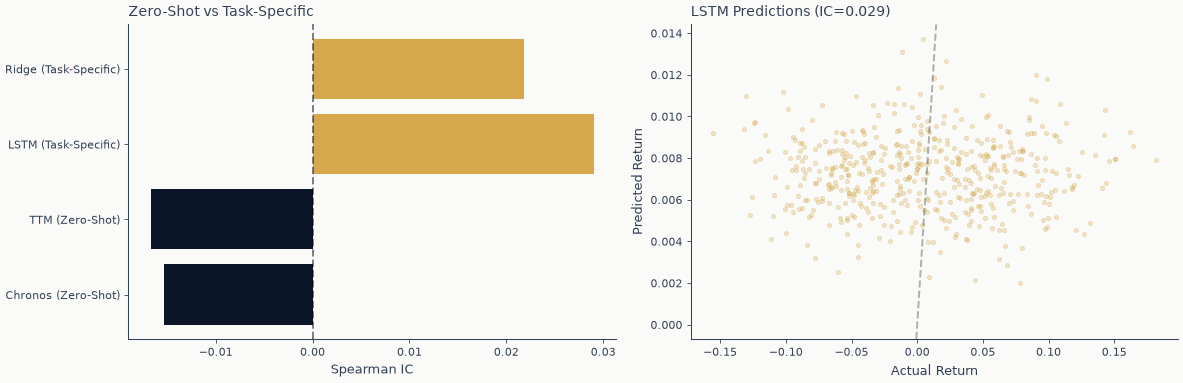

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

available_rows = [r for r in rows if r["Spearman IC"] is not None]
model_names = [r["Model"] for r in available_rows]
ics = [r["Spearman IC"] for r in available_rows]
bar_colors = [
    COLORS["blue"] if r["Type"] == "Foundation" else COLORS["amber"] for r in available_rows
]
axes[0].barh(model_names, ics, color=bar_colors)
axes[0].set_xlabel("Spearman IC")
axes[0].set_title("Zero-Shot vs Task-Specific")
axes[0].axvline(0, color="k", linestyle="--", alpha=0.5)

sample_n = min(500, len(y_test_lstm))
axes[1].scatter(
    y_test_lstm[:sample_n],
    y_pred_lstm[:sample_n],
    alpha=0.3,
    s=10,
    color=COLORS["amber"],
)
axes[1].set_xlabel("Actual Return")
axes[1].set_ylabel("Predicted Return")
axes[1].set_title(f"LSTM Predictions (IC={lstm_ic:.3f})")
axes[1].axline((0, 0), slope=1, color="k", linestyle="--", alpha=0.3)

plt.tight_layout()
fig.show()

## Why Zero-Shot Fails on Finance

The results above are consistent with recent literature. Key findings:

- **Negative $R^2$**: Rahimikia et al. (2025) report that
  Chronos and TimesFM achieve $R^2$ of $-1.37\%$ and $-2.80\%$ on S&P 500
  data -- worse than predicting the mean
- **Negative transfer**: DELPHYNE shows that adding financial
  data to pre-training *hurts* general benchmarks while still failing on finance
- **Root causes**: Near-zero autocorrelation, heavy tails, non-stationarity,
  and adversarial dynamics (exploited patterns disappear) create a fundamental
  distributional mismatch with pre-training corpora
- **Pretraining corpus leakage**: Beyond standard temporal splits, the
  pretraining corpus itself is a leakage channel -- if TSFMs were trained on
  data overlapping the evaluation period, zero-shot claims are compromised
- **Risk forecasting differs**: Volatility and VaR prediction show more
  favorable TSFM results in the cited literature because the target exhibits
  stronger transferable structure (trend, clustering, mean reversion)

See Section 13.6 for the full evidence review, including second-generation
models (Chronos-2, Moirai-MoE) and the efficiency frontier.

## sktime ChronosForecaster

The sktime library provides a `ChronosForecaster` wrapper that integrates
Amazon's Chronos model into the sktime forecasting API. This gives access
to Chronos through a familiar `fit`/`predict` interface with proper
temporal handling.

**Dependency note**: sktime's neural forecasters require `neuralforecast`, which
depends on `ray` — and ray does not yet support Python 3.14
([ray-project/ray#56434](https://github.com/ray-project/ray/issues/56434)).
Once ray adds 3.14 wheels, install via `uv pip install neuralforecast`
and uncomment the demo below.

In [18]:
# from sktime.forecasting.chronos import ChronosForecaster
#
# from data import load_etfs
#
# # Load SPY univariate series for demonstration
# spy = load_etfs(symbols=["SPY"]).sort("timestamp")
# spy_pd = spy.select(["timestamp", "close"]).to_pandas().set_index("timestamp")["close"]
#
# # Train/test split
# split = int(len(spy_pd) * 0.8)
# y_train_sk = spy_pd.iloc[:split]
#
# # Fit and predict
# forecaster = ChronosForecaster(
#     model_path="amazon/chronos-t5-small",
#     config={"num_samples": CHRONOS_NUM_SAMPLES},
# )
# forecaster.fit(y_train_sk, fh=list(range(1, PREDICTION_LENGTH + 1)))
# y_pred_sk = forecaster.predict()
#
# print(f"sktime ChronosForecaster: predicted {len(y_pred_sk)} steps")
# print(y_pred_sk)

## Key Takeaways

1. **Zero-shot TSFMs underperform on finance**: Pre-trained models like
   Chronos and TTM produce near-zero or negative IC on ETF return prediction
   in this notebook and in Rahimikia et al. (2025)
2. **Task-specific training adds signal**: a small 2-layer LSTM trained on
   domain data achieves a higher IC than the zero-shot foundation models here
3. **Negative transfer is documented**: DELPHYNE shows that adding
   financial data to the pre-training mix can hurt benchmark performance
4. **Fine-tuning is the active research direction**: adapter layers and
   LoRA on financial data require labelled domain data, which reintroduces
   the data and supervision constraints of the task-specific paradigm
5. **Baselines matter**: Ridge regression on raw context windows provides
   a non-trivial baseline, reinforcing the "Are Transformers Effective"
   message from Section 13.4

**Next**: See `10_uncertainty` for quantifying prediction uncertainty
with MC Dropout and Deep Ensembles.

**Book**: Section 13.6 discusses foundation models alongside the broader
toolkit of non-attention architectures.